Data structure:
sleep-edf-database-expanded-1.0.0/
├── sleep-cassette/
│   ├── SC4001E0-PSG.edf
│   ├── SC4001EC-Hypnogram.edf
│   ├── SC4002E0-PSG.edf
│   ├── SC4002EC-Hypnogram.edf
│   ├── ...
└── sleep-telemetry/
    ├── ST7001E0-PSG.edf
    ├── ST7001EC-Hypnogram.edf
    ├── ST7002E0-PSG.edf
    ├── ST7002EC-Hypnogram.edf
    ├── ...

Folder sleep-cassette thường là dữ liệu ghi tại nhà (ambulatory) với các bản ghi dài.
Folder sleep-telemetry: Thường là dữ liệu truyền từ xa trong phòng thí nghiệm.

File SC4001E0-PSG.edf là sóng, còn file SC4001EC-Hypnogram.edf mới là nhãn (kết quả bác sĩ đã đọc)

File information:
- his_id: X, sex: 2, first_name: Female, last_name: 33yr
- nchan: 7 (Kenh), sfreq: 100Hz (Tan so moi giay), Duration: 79,500 giây (22 gio)
    - EEG Fpz-Cz: Điện não đồ (vùng trán) - Xác định giấc ngủ nông/sâu qua sóng Delta, Theta, hay các k-complex.
    - EEG Pz-Oz: Điện não đồ (vùng chẩm) - Rất quan trọng để thấy sóng Alpha khi người bệnh nhắm mắt nhưng còn thức.
    - EOG horizontal: Điện nhãn đồ - Đo chuyển động mắt. Cần thiết để xác định giai đoạn REM (mắt đảo nhanh).
    - EMG submental: Điện cơ (dưới cằm) - Đo trương lực cơ. Trong giai đoạn REM, cơ bắp sẽ bị "liệt" hoàn toàn (điện cơ phẳng).
    - Resp oro-nasal: Hô hấp (mũi-miệng) - Theo dõi nhịp thở, dùng để phát hiện ngưng thở khi ngủ.
    - Temp rectal: Nhiệt độ trực tràng - Theo dõi sự thay đổi thân nhiệt trong chu kỳ sinh học.
    - Event marker: Đánh dấu sự kiện - Các ghi chú của kỹ thuật viên hoặc máy trong lúc đo.

Extracting EDF parameters from sleep-edf-database-expanded-1.0.0/sleep-cassette/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/var/folders/l0/ldvtdl8d4h54k4qpgmg_hfp00000gn/T/ipykernel_3214/2302882187.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(origin_folder_path + '/' + cassette_folder_path + '/SC4001E0-PSG.edf', preload=True)
/var/folders/l0/ldvtdl8d4h54k4qpgmg_hfp00000gn/T/ipykernel_3214/2302882187.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(origin_folder_path + '/' + cassette_folder_path + '/SC4001E0-PSG.edf', preload=True)
/var/folders/l0/ldvtdl8d4h54k4qpgmg_hfp00000gn/T/ipykernel_3214/2302882187.py:10: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(origin_folder_path + '/' + cassette_folder_path + '/SC4001E0-PSG.edf', preload=True)
/var/folders/l0/ldvtdl8d4h54k4qpgmg_hfp00000gn/T/ipykernel_3214/2302882187.py:16: RuntimeWa

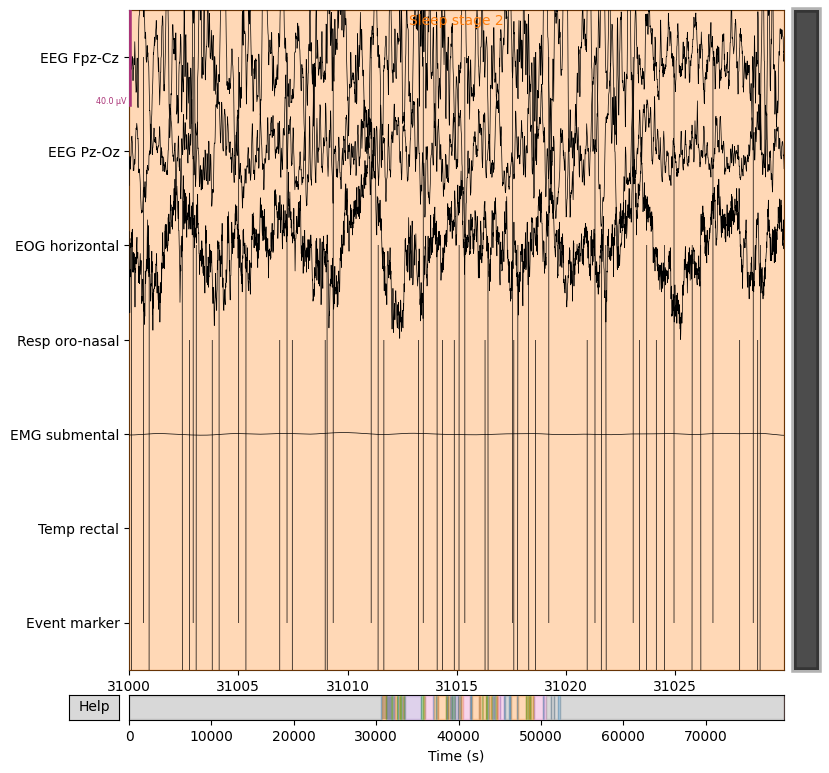

In [17]:
import mne
import matplotlib.pyplot as plt

origin_folder_path = 'sleep-edf-database-expanded-1.0.0'
cassette_folder_path = 'sleep-cassette'
telemetry_folder_path = 'sleep-telemetry'

try:
    # 1. Load file sóng
    raw = mne.io.read_raw_edf(origin_folder_path + '/' + cassette_folder_path + '/SC4001E0-PSG.edf', preload=True)

    # 2. Load file nhãn (Hypnogram)
    annot = mne.read_annotations(origin_folder_path + '/' + cassette_folder_path + '/SC4001EC-Hypnogram.edf')

    # 3. Gán nhãn vào sóng
    raw.set_annotations(annot)

    # Xem đoạn giây thứ 31000 để thấy sự thay đổi nhãn rõ rệt
    raw.plot(start=31000, duration=30)
except FileNotFoundError as e:
    print(f"Error: {e}. Please check if the file paths are correct and the files exist.")